In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# load data
home_df = pd.read_csv('../data/processed/team_home_stats.csv')
away_df = pd.read_csv('../data/processed/team_away_stats.csv')

In [4]:
# Extract team names and ratings
home_rating = home_df[['Team', 'Rating']].copy()
away_rating = away_df[['Team', 'Rating']].copy()

In [5]:
# Rename columns for clarity
home_rating = home_rating.rename(columns={'Rating': 'Home_Rating'})
away_rating = away_rating.rename(columns={'Rating': 'Away_Rating'})

In [6]:
# Merge
comparison = pd.merge(home_rating, away_rating, on='Team', how='inner')

In [7]:
# Calculate difference
comparison['Diff'] = comparison['Home_Rating'] - comparison['Away_Rating']

In [8]:
# Sort by difference
comparison_sorted = comparison.sort_values(by='Diff', ascending=False).reset_index(drop=True)

In [9]:
# Classify teams based on home-away difference
home_dominant = comparison_sorted[comparison_sorted['Diff'] > 0]

balanced = comparison_sorted[comparison_sorted['Diff'] == 0]

away_dominant = comparison_sorted[comparison_sorted['Diff'] < 0]

In [10]:
# Print results by category
print("=" * 55)
print("🏠 HOME DOMINANT (Home - Away > 0)")
print("=" * 55)
for _, row in home_dominant.iterrows():
    print(f"{row['Team']}: Home {row['Home_Rating']:.2f} vs Away {row['Away_Rating']:.2f} (Diff {row['Diff']:+.2f})")

print("\n" + "=" * 55)
print("⚖️ BALANCED (Home - Away = 0)")
print("=" * 55)
for _, row in balanced.iterrows():
    print(f"{row['Team']}: Home {row['Home_Rating']:.2f} vs Away {row['Away_Rating']:.2f} (Diff {row['Diff']:+.2f})")

print("\n" + "=" * 55)
print("🚀 AWAY DOMINANT (Home - Away < 0)")
print("=" * 55)
for _, row in away_dominant.iterrows():
    print(f"{row['Team']}: Home {row['Home_Rating']:.2f} vs Away {row['Away_Rating']:.2f} (Diff {row['Diff']:+.2f})")

🏠 HOME DOMINANT (Home - Away > 0)
Burnley: Home 6.56 vs Away 6.32 (Diff +0.24)
Liverpool: Home 6.79 vs Away 6.60 (Diff +0.19)
Fulham: Home 6.66 vs Away 6.49 (Diff +0.17)
Brentford: Home 6.74 vs Away 6.58 (Diff +0.16)
Sunderland: Home 6.66 vs Away 6.51 (Diff +0.15)
Manchester United: Home 6.83 vs Away 6.68 (Diff +0.15)
Newcastle: Home 6.68 vs Away 6.54 (Diff +0.14)
Leeds: Home 6.67 vs Away 6.54 (Diff +0.13)
Aston Villa: Home 6.64 vs Away 6.52 (Diff +0.12)
Wolves: Home 6.50 vs Away 6.39 (Diff +0.11)
Manchester City: Home 6.94 vs Away 6.84 (Diff +0.10)
Brighton: Home 6.65 vs Away 6.56 (Diff +0.09)
Bournemouth: Home 6.70 vs Away 6.63 (Diff +0.07)
Arsenal: Home 6.82 vs Away 6.76 (Diff +0.06)
West Ham: Home 6.61 vs Away 6.58 (Diff +0.03)
Everton: Home 6.69 vs Away 6.67 (Diff +0.02)
Nottingham Forest: Home 6.62 vs Away 6.60 (Diff +0.02)

⚖️ BALANCED (Home - Away = 0)
Crystal Palace: Home 6.62 vs Away 6.62 (Diff +0.00)

🚀 AWAY DOMINANT (Home - Away < 0)
Chelsea: Home 6.63 vs Away 6.65 (Diff -0

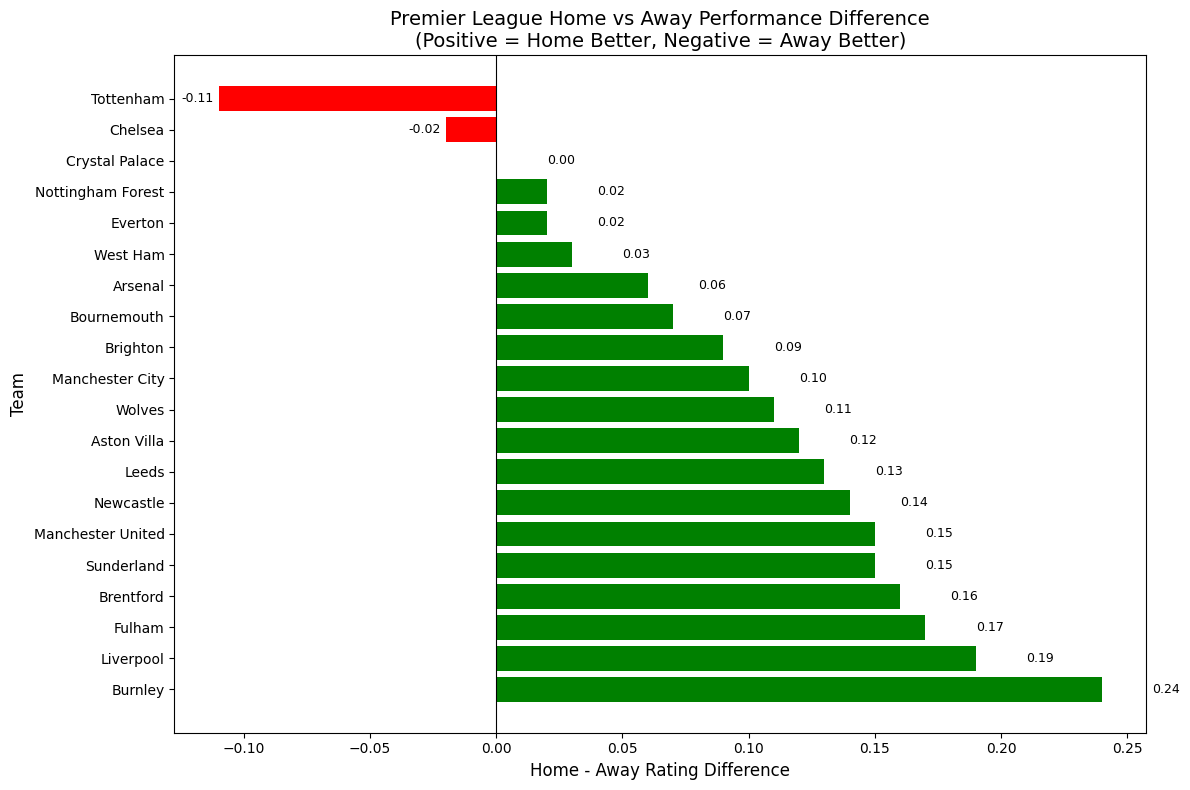

In [11]:
# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

# Create colors: green for positive, red for negative
colors = ['green' if x > 0 else 'red' for x in comparison_sorted['Diff']]

# Draw horizontal bar chart
bars = ax.barh(comparison_sorted['Team'], comparison_sorted['Diff'], color=colors)

# Add vertical line at zero
ax.axvline(x=0, color='black', linewidth=0.8)

# Labels and title
ax.set_xlabel('Home - Away Rating Difference', fontsize=12)
ax.set_ylabel('Team', fontsize=12)
ax.set_title('Premier League Home vs Away Performance Difference\n(Positive = Home Better, Negative = Away Better)', fontsize=14)

# Add value labels with position adjustment for negative values
for bar, diff in zip(bars, comparison_sorted['Diff']):
    if diff >= 0:
        # Positive values: label on the right side of the bar
        x_pos = bar.get_width() + 0.02
        ha = 'left'
    else:
        # Negative values: label on the left side of the bar
        x_pos = bar.get_width() - 0.002
        ha = 'right'
    
    ax.text(x_pos, 
            bar.get_y() + bar.get_height()/2, 
            f'{diff:.2f}', 
            va='center', 
            ha=ha, 
            fontsize=9)
plt.tight_layout()
plt.savefig('../home_away_analysis/images/home_away_rating_diff.png', dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Export results
output_path = '../data/processed/home_away_comparison.csv'
comparison_sorted.to_csv(output_path, index=False)
print(f'Results saved to: {output_path}')

Results saved to: ../data/processed/home_away_comparison.csv
